In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tanushreeadhikari18","key":"7ee52eb360e0bbed7601c4cec203dca8"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip skin-cancer-mnist-ham10000.zip -d /content/HAM10000

Streaming output truncated to the last 5000 lines.
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: /content/HAM10000/ham10000_images_part_2/ISIC_0029337.jpg  


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_dir = "/content/HAM10000"

df = pd.read_csv(os.path.join(data_dir, "HAM10000_metadata.csv"))

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Shape: (10015, 7)

Missing values:
 lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


In [ ]:
df['age'].fillna(df['age'].median(), inplace=True)
df['localization'].fillna('unknown', inplace=True)

/tmp/ipykernel_2613/3030693507.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_2613/3030693507.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
df = df.drop_duplicates(subset='lesion_id')
print("After removing duplicates:", df.shape)

After removing duplicates: (7470, 7)


In [ ]:
image_dir_1 = os.path.join(data_dir, "HAM10000_images_part_1")
image_dir_2 = os.path.join(data_dir, "HAM10000_images_part_2")

image_paths = {}

for img in os.listdir(image_dir_1):
    image_paths[img.split(".")[0]] = os.path.join(image_dir_1, img)

for img in os.listdir(image_dir_2):
    image_paths[img.split(".")[0]] = os.path.join(image_dir_2, img)

df['image_path'] = df['image_id'].map(image_paths.get)

df = df.dropna(subset=['image_path'])

In [ ]:
label_mapping = {
    'nv': 0,
    'mel': 1,
    'bkl': 2,
    'bcc': 3,
    'akiec': 4,
    'vasc': 5,
    'df': 6
}

df['label'] = df['dx'].map(label_mapping)

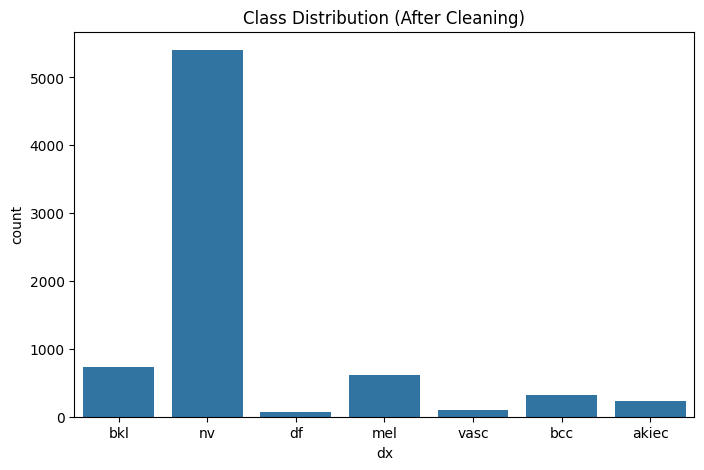

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='dx', data=df)
plt.title("Class Distribution (After Cleaning)")
plt.show()

In [ ]:
df.to_csv("/content/cleaned_metadata.csv", index=False)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd

df = pd.read_csv("/content/cleaned_metadata.csv")

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/HAM10000/HAM10000_images_part_1/ISIC_...,2
1,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/HAM10000/HAM10000_images_part_1/ISIC_...,2
2,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/HAM10000/HAM10000_images_part_2/ISIC_...,2
3,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,/content/HAM10000/HAM10000_images_part_1/ISIC_...,2
4,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back,/content/HAM10000/HAM10000_images_part_1/ISIC_...,2


In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (5976, 9)
Validation: (1494, 9)


In [ ]:
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 5976 validated image filenames belonging to 7 classes.
Found 1494 validated image filenames belonging to 7 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df['label'])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label']
)
class_weights_dict = {k: min(v, 5.0) for k, v in class_weights_dict.items()}


print(class_weights_dict)

{'0': np.float64(0.19748190740557153), '1': np.float64(1.7387256328193192), '2': np.float64(1.466863033873343), '3': np.float64(3.25845147219193), '4': np.float64(4.6907378335949765), '5': 5.0, '6': 5.0}


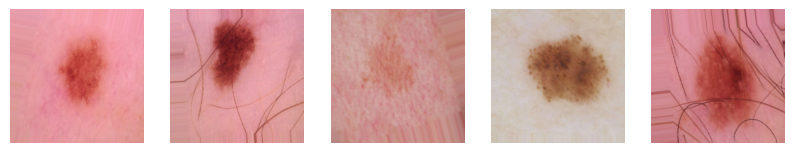

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras import layers, Model

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Membership (normal classification)
membership = layers.Dense(7, activation='softmax', name='membership')(x)

# Non-membership (uncertainty)
non_membership = layers.Dense(7, activation='sigmoid', name='non_membership')(x)

model = Model(inputs=base_model.input, outputs=[membership, non_membership])

In [ ]:
import tensorflow as tf

def bipolar_fuzzy_loss(y_true, y_pred):
    membership, non_membership = y_pred

    # Standard classification loss
    ce_loss = tf.keras.losses.categorical_crossentropy(y_true, membership)

    # Fuzzy constraint: membership + non_membership <= 1
    fuzzy_constraint = tf.reduce_mean(
        tf.maximum(0.0, membership + non_membership - 1)
    )

    return ce_loss + 0.5 * fuzzy_constraint

In [ ]:
model.compile(
    optimizer='adam',
    loss={
        'membership': 'categorical_crossentropy',
        'non_membership': 'binary_crossentropy'
    },
    loss_weights={
        'membership': 1.0,
        'non_membership': 0.1
    },
    metrics={
        'membership': 'accuracy',
        'non_membership': 'accuracy'
    }
)

In [ ]:
def fuzzy_generator(generator):
    while True:
        x, y = next(generator)

        # membership = original labels
        y_membership = y

        # non-membership = inverse (uncertainty)
        y_non_membership = 0.2 * (1 - y)

        yield x, {
            'membership': y_membership,
            'non_membership': y_non_membership
        }

In [ ]:
train_gen_fuzzy = fuzzy_generator(train_generator)
val_gen_fuzzy = fuzzy_generator(val_generator)

In [ ]:
history_fuzzy = model.fit(
    train_gen_fuzzy,
    validation_data=val_gen_fuzzy,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    epochs=10
)

Epoch 1/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 142s 668ms/step - loss: 0.6174 - membership_accuracy: 0.8333 - membership_loss: 0.4923 - non_membership_accuracy: 0.0832 - non_membership_loss: 1.2535 - val_loss: 3.5182 - val_membership_accuracy: 0.6954 - val_membership_loss: 3.3431 - val_non_membership_accuracy: 0.0161 - val_non_membership_loss: 1.9883
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 107s 575ms/step - loss: 0.5756 - membership_accuracy: 0.8258 - membership_loss: 0.5177 - non_membership_accuracy: 0.1233 - non_membership_loss: 0.5779 - val_loss: 21.2258 - val_membership_accuracy: 0.7289 - val_membership_loss: 20.5139 - val_non_membership_accuracy: 0.0000e+00 - val_non_membership_loss: 7.6878
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 108s 578ms/step - loss: 0.5061 - membership_accuracy: 0.8395 - membership_loss: 0.4546 - non_membership_accuracy: 0.1769 - non_membership_loss: 0.5167 - val_loss: 3.5049 - val_membership_accuracy: 0.7811 - val_membership_loss: 3.3510 - val_non_membership_accurac

In [ ]:
results = model.evaluate(val_gen_fuzzy, steps=len(val_generator))
print(results)

47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - loss: 1.6692 - membership_accuracy: 0.7871 - membership_loss: 1.6176 - non_membership_accuracy: 0.1908 - non_membership_loss: 0.4846
[1.6691609621047974, 1.6175614595413208, 0.48455730080604553, 0.7871485948562622, 0.19076305627822876]


In [ ]:
membership_acc = results[3]
print("Final Accuracy:", membership_acc)

Final Accuracy: 0.6111111044883728


In [ ]:
results = model.evaluate(val_gen_fuzzy, steps=len(val_generator), return_dict=True)
print(results)

47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 215ms/step - loss: 1.5912 - membership_accuracy: 0.7938 - membership_loss: 1.5328 - non_membership_accuracy: 0.1934 - non_membership_loss: 0.4832
{'loss': 1.5912221670150757, 'membership_accuracy': 0.7938420176506042, 'membership_loss': 1.53281569480896, 'non_membership_accuracy': 0.19344042241573334, 'non_membership_loss': 0.4832000434398651}


In [ ]:
sakaguchi_matrix = np.array([
    [1.0, 0.2, 0.6, 0.3, 0.2, 0.1, 0.1],
    [0.2, 1.0, 0.3, 0.5, 0.6, 0.1, 0.1],
    [0.6, 0.3, 1.0, 0.4, 0.3, 0.1, 0.1],
    [0.3, 0.5, 0.4, 1.0, 0.6, 0.1, 0.1],
    [0.2, 0.6, 0.3, 0.6, 1.0, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 1.0, 0.2],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 1.0]
])

sakaguchi_matrix_tf = tf.constant(sakaguchi_matrix, dtype=tf.float32)

def sakaguchi_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    similarity = tf.matmul(y_true, sakaguchi_matrix_tf)
    penalty = tf.reduce_mean(tf.square(y_pred - similarity))
    return ce + 0.2 * penalty

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={
        'membership': sakaguchi_loss,
        'non_membership': 'binary_crossentropy'
    },
    loss_weights={
        'membership': 1.0,
        'non_membership': 0.1
    },
    metrics={
        'membership': 'accuracy',
        'non_membership': 'accuracy'
    }
)

In [ ]:
history_sakaguchi = model.fit(
    train_gen_fuzzy,
    validation_data=val_gen_fuzzy,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    epochs=5
)

Epoch 1/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 146s 691ms/step - loss: 0.3618 - membership_accuracy: 0.8946 - membership_loss: 0.3167 - non_membership_accuracy: 0.2237 - non_membership_loss: 0.4498 - val_loss: 1.2594 - val_membership_accuracy: 0.7952 - val_membership_loss: 1.2065 - val_non_membership_accuracy: 0.2744 - val_non_membership_loss: 0.4766
Epoch 2/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 107s 577ms/step - loss: 0.3500 - membership_accuracy: 0.9014 - membership_loss: 0.3052 - non_membership_accuracy: 0.2010 - non_membership_loss: 0.4494 - val_loss: 1.1401 - val_membership_accuracy: 0.7791 - val_membership_loss: 1.0983 - val_non_membership_accuracy: 0.2784 - val_non_membership_loss: 0.4712
Epoch 3/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 105s 561ms/step - loss: 0.3288 - membership_accuracy: 0.9106 - membership_loss: 0.2840 - non_membership_accuracy: 0.2048 - non_membership_loss: 0.4491 - val_loss: 1.0187 - val_membership_accuracy: 0.7959 - val_membership_loss: 0.9705 - val_non_membership_accuracy: 0.2671

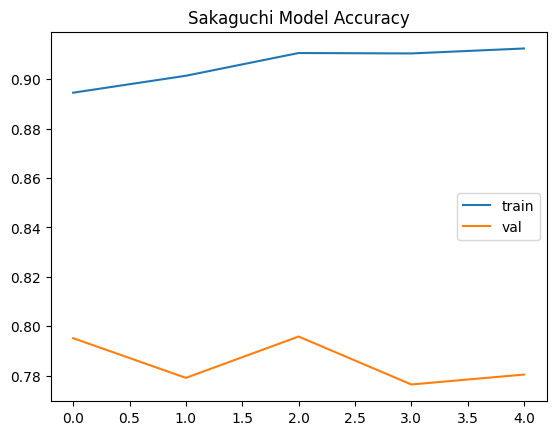

In [ ]:
plt.plot(history_sakaguchi.history['membership_accuracy'], label='train')
plt.plot(history_sakaguchi.history['val_membership_accuracy'], label='val')
plt.legend()
plt.title("Sakaguchi Model Accuracy")
plt.show()

In [ ]:
results = model.evaluate(
    val_gen_fuzzy,
    steps=len(val_generator),
    return_dict=True
)

print(results)

47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 330ms/step - loss: 0.9481 - membership_accuracy: 0.7858 - membership_loss: 0.8995 - non_membership_accuracy: 0.2590 - non_membership_loss: 0.4591
{'loss': 0.9480563998222351, 'membership_accuracy': 0.7858099341392517, 'membership_loss': 0.8994633555412292, 'non_membership_accuracy': 0.2590361535549164, 'non_membership_loss': 0.45905250310897827}


In [ ]:
print("Final Accuracy:", results['membership_accuracy'])

Final Accuracy: 0.7858099341392517


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 176s 811ms/step - accuracy: 0.6784 - loss: 1.0786 - val_accuracy: 0.7811 - val_loss: 0.6469
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 107s 572ms/step - accuracy: 0.7498 - loss: 0.7568 - val_accuracy: 0.7858 - val_loss: 0.6197
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 106s 569ms/step - accuracy: 0.7657 - loss: 0.6831 - val_accuracy: 0.7798 - val_loss: 0.6123
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 107s 573ms/step - accuracy: 0.7733 - loss: 0.6600 - val_accuracy: 0.7892 - val_loss: 0.6139
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 105s 564ms/step - accuracy: 0.7771 - loss: 0.6362 - val_accuracy: 0.7871 - val_loss: 0.6119
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 107s 573ms/step - accuracy: 0.7885 - loss: 0.6129 - val_accuracy: 0.7791 - val_loss: 0.6182
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 106s 570ms/step - accuracy: 0.7898 - loss: 0.6016 - val_accuracy: 0.7905 - val_loss: 0.6206
Epoch 8/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 105s 562ms/step - accuracy: 0.7898 -

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights_dict
)

Epoch 1/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 143s 672ms/step - accuracy: 0.7480 - loss: 0.7366 - val_accuracy: 0.7590 - val_loss: 1.2915
Epoch 2/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 107s 571ms/step - accuracy: 0.7597 - loss: 0.6849 - val_accuracy: 0.7584 - val_loss: 1.3836
Epoch 3/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 109s 584ms/step - accuracy: 0.7657 - loss: 0.6610 - val_accuracy: 0.7610 - val_loss: 1.1317
Epoch 4/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 107s 575ms/step - accuracy: 0.7793 - loss: 0.6294 - val_accuracy: 0.7671 - val_loss: 0.9746
Epoch 5/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 108s 578ms/step - accuracy: 0.7892 - loss: 0.6033 - val_accuracy: 0.7778 - val_loss: 0.8140


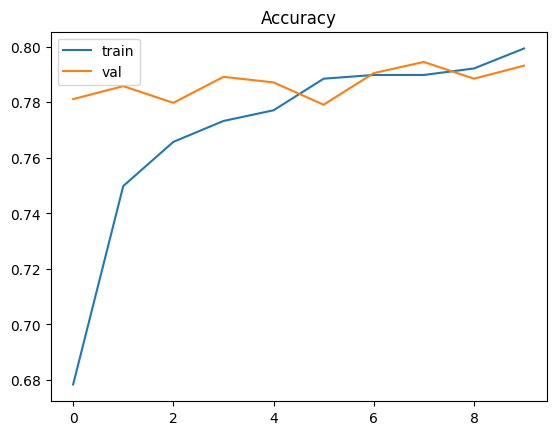

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
model.save("/content/skin_cancer_fuzzy_model.keras")

In [ ]:
from google.colab import files
files.download("/content/skin_cancer_fuzzy_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("/content/skin_cancer_model.h5")

In [ ]:
files.download("/content/skin_cancer_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving vas2.jpg to vas2.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


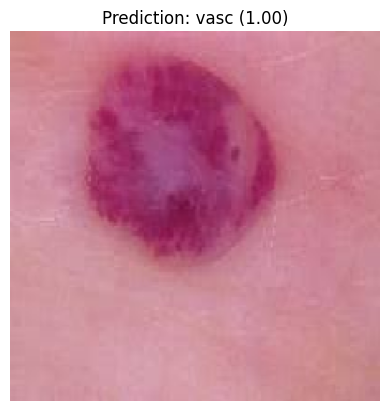

Predicted Class: vasc
Confidence: 0.9999964


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Label mapping
labels = {
    0: 'nv',
    1: 'mel',
    2: 'bkl',
    3: 'bcc',
    4: 'akiec',
    5: 'vasc',
    6: 'df'
}

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
membership_pred, non_membership_pred = model.predict(img_array)

pred_class = np.argmax(membership_pred)
confidence = np.max(membership_pred)

# Show image
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {labels[pred_class]} ({confidence:.2f})")
plt.show()

print("Predicted Class:", labels[pred_class])
print("Confidence:", confidence)

In [ ]:
top3 = np.argsort(membership_pred[0])[-3:][::-1]

for i in top3:
    print(f"{labels[i]}: {membership_pred[0][i]:.4f}")

vasc: 1.0000
nv: 0.0000
mel: 0.0000


In [ ]:
import tensorflow as tf

# Save WITHOUT optimizer (avoids compatibility issues)
model.save("/content/clean_model.h5", include_optimizer=False)


In [ ]:
from google.colab import files
files.download("/content/clean_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save_weights("/content/model_weights.weights.h5")

In [ ]:
from google.colab import files
files.download("/content/model_weights.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>